In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time


In [2]:
class graphWithComplement:

    def __init__(self, n, p=None):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        if p is None:
            self.graph = nx.empty_graph(n)
            self.complement = nx.complete_graph(n)
        else:
            self.graph = nx.fast_gnp_random_graph(n, p)
            self.complement = nx.complement(self.graph)

    def add_edge(self, u, v):
        self.graph.add_edge(u, v)
        self.complement.remove_edge(u, v)
    
    def remove_edge(self, u, v):
        self.graph.remove_edge(u, v)
        self.complement.add_edge(u, v)
    
    def has_edge(self, u, v):
        return self.graph.has_edge(u, v)
    
    def number_of_common_neighbors(self, u, v, m=None):
        if m is None or m<self.half_of_all_edges:
            return len(nx.common_neighbors(self.graph, u, v))
        else:
            return self.n - 2 - len((self.complement.adj[u].keys() | self.complement.adj[v].keys()) - {u,v})

In [3]:
n = 500
alpha = 1 #lagrangian multiplier for sum of P = 1 constraint
theta1 = 2.2
G = graphWithComplement(n, p=0.5)
m= G.graph.number_of_edges()
t = sum(nx.triangles(G.graph).values()) // 3
its = 500000
burn_in = 50000
up_edges = []
up_tris = []
down_edges = []
down_tris = []

#upsweep
theta2_vals = np.linspace(0, 5, 100)
for theta2 in theta2_vals:
    H_old_sq = (alpha + theta1 * m - theta2 * t) ** 2
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -G.number_of_common_neighbors(i, j, m)
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = G.number_of_common_neighbors(i, j, m)
            delta_m = 1
            G.add_edge(i, j)
        
        t_new = t + delta_t
        m_new = m + delta_m
        H_new_sq = (alpha + theta1 * m_new - theta2 * t_new) ** 2

        dH = H_old_sq - H_new_sq
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
            H_old_sq = H_new_sq
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    elapsed = time.time() - start_time
    print(f"theta2 = {theta2:.4f}, time = {elapsed:.2f} s")

    up_edges.append(total_edges / (its-burn_in))
    up_tris.append(total_tris / (its-burn_in))

#downsweep
for theta2 in reversed(theta2_vals):
    H_old_sq = (alpha + theta1 * m - theta2 * t) ** 2
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -G.number_of_common_neighbors(i, j, m) 
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = G.number_of_common_neighbors(i, j, m)
            delta_m = 1
            G.add_edge(i, j)
        
        t_new = t + delta_t
        m_new = m + delta_m
        H_new_sq = (alpha + theta1 * m_new - theta2 * t_new) ** 2

        dH = H_old_sq - H_new_sq
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
            H_old_sq = H_new_sq
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    elapsed = time.time() - start_time
    print(f"theta2 = {theta2:.4f}, time = {elapsed:.2f} s")

    down_edges.append(total_edges / (its-burn_in))
    down_tris.append(total_tris / (its-burn_in))

plt.figure()
plt.scatter(theta2_vals, up_edges, label='upsweep', marker = 'o')
plt.scatter(theta2_vals[::-1], down_edges, label = 'downsweep', marker = '^')

plt.figure()
plt.scatter(theta2_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(theta2_vals[::-1], down_tris, label = 'downsweep', marker = '^')

plt.show()


KeyboardInterrupt: 

In [4]:
import mpmath 
mpmath.mp.dps = 50




In [5]:
def f(alpha, beta, nc2):
    nc2 = int(nc2)
    total = 0
    for m in range(nc2+1):
        square_term = alpha - beta * m
        total += mpmath.binomial(nc2, m)*mpmath.exp(-square_term * square_term)
    return total - 1

In [6]:
def derivative(alpha, beta, nc2):
    nc2 = int(nc2)
    total = 0
    for m in range(nc2+1):
        square_term = alpha - beta * m
        total += mpmath.binomial(nc2, m)*mpmath.exp(-square_term * square_term)*(-2*square_term)
    return total

In [7]:
beta = 1
n=100
nc2 = mpmath.binomial(n, 2)
alpha = mpmath.findroot(lambda alpha: f(alpha, beta, nc2), 0, derivative = lambda alpha: derivative(alpha, beta, nc2), tol = 1e-10, verify=False)
print(alpha, f(alpha, beta, nc2))

-2.1076847854672156058432564404991120706356454318558 1.8932971203503117275095073203444418023562274320189e-16


In [8]:
import mpmath
import matplotlib.pyplot as plt
import time

# Set high precision
mpmath.dps = 50

def f(alpha, beta, nc2):
    nc2 = int(nc2)
    total = 0
    prev_total = -1
    for m in range(nc2 + 1):
        square_term = alpha - beta * m
        total += mpmath.binomial(nc2, m) * mpmath.exp(-square_term * square_term)
        if total == prev_total:
            break
        prev_total = total
    return total - 1

def derivative(alpha, beta, nc2):
    nc2 = int(nc2)
    total = 0
    prev_total = -1
    for m in range(nc2 + 1):
        square_term = alpha - beta * m
        total += mpmath.binomial(nc2, m) * mpmath.exp(-square_term * square_term) * (-2 * square_term)
        if total == prev_total:
            break
        prev_total = total
    return total

def calculate_entropy(alpha, beta, nc2):
    nc2 = int(nc2)
    total_entropy = 0
    prev_total = -1
    for m in range(nc2 + 1):
        square_term = alpha - beta * m
        p = mpmath.exp(-square_term * square_term)
        entropy = p * mpmath.sqrt(-mpmath.log(p)) + (mpmath.sqrt(mpmath.pi) / 2) * mpmath.erfc(mpmath.sqrt(-mpmath.log(p)))
        total_entropy += mpmath.binomial(nc2, m) * entropy
        if total_entropy == prev_total:
            break
        prev_total = total_entropy
    return total_entropy

n_values = range(10, 100, 10)

mpmath.mp.dps = 50
plt.figure(figsize=(10, 6))
beta_alpha_lists = []
for beta in [0.05, 0.1, 0.3, 1]:
    results_n = []
    results_entropy = []
    alpha_list = []
    start_guess = 0
    for n_val in n_values:
        start_time = time.time()
        n = mpmath.mpf(n_val)
        nc2 = mpmath.binomial(n, 2)
        try:
            alpha = mpmath.findroot(lambda alpha: f(alpha, beta, nc2), start_guess, derivative = lambda alpha: derivative(alpha, beta, nc2), tol = 1e-10, maxsteps = 1000)
            alpha_list.append((n_val, float(alpha)))
            start_guess = alpha  # Update start guess for next iteration
            entropy = calculate_entropy(alpha, beta, nc2)
            
            results_n.append(n_val)
            results_entropy.append(float(entropy)) 
            
            print(f"n = {n_val}, nc2 = {int(nc2)}, alpha = {alpha}, Entropy = {entropy} (took {time.time() - start_time:.2f}s)")
        
        except Exception as e:
            print(f"  Failed to find root for n = {n_val}: {e}, {beta}")
    beta_alpha_lists.append((beta, alpha_list))
    if results_n:
        plt.plot(results_n, results_entropy, 'o-', label=f'beta={beta}')
    else:
        print("No results to plot.")

beta = 0
results_n = []
results_entropy = []
alpha_list = []
for n_val in range(10, 100, 20):
    start_time = time.time()
    n = mpmath.mpf(n_val)
    nc2 = mpmath.binomial(n, 2)
    try:
        alpha = -mpmath.sqrt(nc2*mpmath.log(2))
        alpha_list.append((n_val, float(alpha)))
        square_term = alpha - beta * m
        p = mpmath.exp(-square_term * square_term)
        entropy = p * mpmath.sqrt(-mpmath.log(p)) + (mpmath.sqrt(mpmath.pi) / 2) * mpmath.erfc(mpmath.sqrt(-mpmath.log(p)))
        total_entropy = (2**(nc2)) * entropy
        
        results_n.append(n_val)
        results_entropy.append(float(total_entropy)) 
        
        print(f"n = {n_val}, nc2 = {int(nc2)}, alpha = {alpha}, Entropy = {entropy} (took {time.time() - start_time:.2f}s)")
    
    except Exception as e:
        print(f"  Failed to find root for n = {n_val}: {e}, {beta}")
beta_alpha_lists.append((beta, alpha_list))
if results_n:
     plt.plot(results_n, results_entropy, 'o-', label=f'beta={beta}')
else:
    print("No results to plot.")

print(beta_alpha_lists)
plt.xlabel('n (number of nodes)')
plt.ylabel('Entropy')
plt.title('Entropy vs. n')
plt.grid(True)
plt.legend()
plt.show()

n = 10, nc2 = 45, alpha = -4.6106827877400094781700937521581580664726671707036, Entropy = 5.5273996961549141003401728053286713429666343157181 (took 0.18s)
n = 20, nc2 = 190, alpha = -7.9605753753663735477817711049828455801859600731782, Entropy = 10.481246742479970254360303651801479537908297170172 (took 1.06s)
n = 30, nc2 = 435, alpha = -10.405835657765873990560287331601073743812500895238, Entropy = 14.560197942478419707585874523798875933853350918565 (took 2.72s)


KeyboardInterrupt: 

<Figure size 1000x600 with 0 Axes>

In [ ]:
n = 200
nc2 = mpmath.binomial(n, 2)
beta = 3
start_guess = 0
alpha = mpmath.findroot(lambda alpha: f(alpha, beta, nc2), start_guess, derivative = lambda alpha: derivative(alpha, beta, nc2), tol = 1e-10)
print(alpha, f(alpha, beta, nc2), calculate_entropy(alpha, beta, nc2))
#symmetry 
print(nc2*beta-alpha,f(nc2*beta-alpha, beta, nc2), calculate_entropy(nc2*beta-alpha, beta, nc2))



-0.42214426387951477333703624953515142616335359452487 1.8326281181620585538338657885270081812852185726877e-41 1.4226463217044382617904733885273682042992277343066
59700.422144263879514773337036249535151426163353595 1.8326325977157126683537687200661271271688474669577e-41 1.4226463217044382617904733885273682042992277344078


-0.42214426387951476
Iteration 50000, edges: 838, triangles: 97
Iteration 100000, edges: 47, triangles: 0
Iteration 150000, edges: 2, triangles: 0
Iteration 200000, edges: 0, triangles: 0
Iteration 250000, edges: 1, triangles: 0
Iteration 300000, edges: 0, triangles: 0
Iteration 350000, edges: 0, triangles: 0
Iteration 400000, edges: 0, triangles: 0
Iteration 450000, edges: 0, triangles: 0


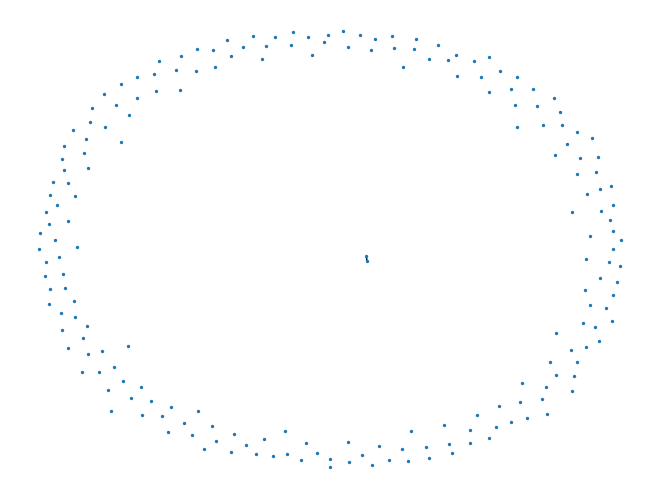

59700.422144263879514758386335415707435458898544312
Iteration 50000, edges: 19088, triangles: 1159036
Iteration 100000, edges: 19837, triangles: 1300967
Iteration 150000, edges: 19897, triangles: 1312806
Iteration 200000, edges: 19900, triangles: 1313400
Iteration 250000, edges: 19900, triangles: 1313400
Iteration 300000, edges: 19900, triangles: 1313400
Iteration 350000, edges: 19900, triangles: 1313400
Iteration 400000, edges: 19900, triangles: 1313400
Iteration 450000, edges: 19900, triangles: 1313400


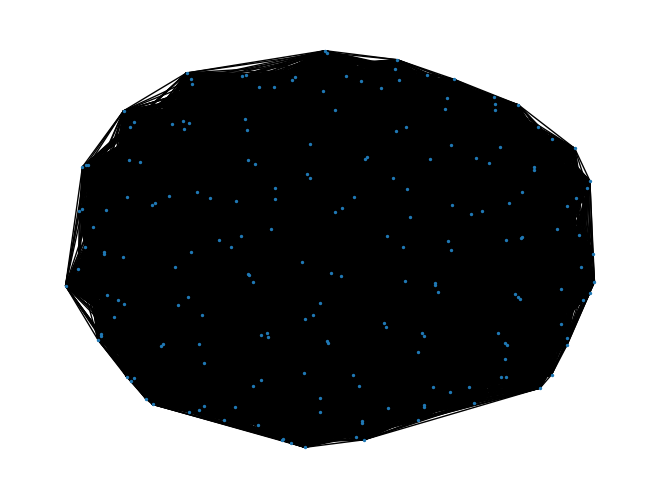

In [ ]:
n = 200
alpha = -0.42214426387951477333703624953515142616335359452487 #lagrangian multiplier for sum of P = 1 constraint
print(alpha)
theta1 = 3
G = graphWithComplement(n, p=0.5)
m= G.graph.number_of_edges()
t = sum(nx.triangles(G.graph).values()) // 3
its = 500000
burn_in = 50000
H_old_sq = (alpha - theta1 * m) ** 2

for _ in range(its):
    if _ % 50000 == 0 and _ > 0:
        print(f"Iteration {_}, edges: {m}, triangles: {t}")
    i, j = np.random.randint(0, n, 2)
    while(i==j):
        i, j = np.random.randint(0, n, 2)
    if G.has_edge(i, j):
        delta_t = -G.number_of_common_neighbors(i, j, m)
        delta_m = -1
        G.remove_edge(i, j)
    else:
        delta_t = G.number_of_common_neighbors(i, j, m)
        delta_m = 1
        G.add_edge(i, j)
    
    t_new = t + delta_t
    m_new = m + delta_m
    H_new_sq = (alpha - theta1 * m_new) ** 2

    dH = H_old_sq - H_new_sq
    if np.log(np.random.uniform()) <= dH:
        m += delta_m
        t += delta_t
        H_old_sq = H_new_sq
    else:
        # revert
        if delta_m == -1:
            G.add_edge(i, j)
        else:
            G.remove_edge(i, j)

nx.draw(G.graph, node_size = 2)
plt.show()
alpha = mpmath.binomial(n, 2)*beta-alpha
print(alpha)
theta1 = 3
G = graphWithComplement(n, p=0.5)
m= G.graph.number_of_edges()
t = sum(nx.triangles(G.graph).values()) // 3
its = 500000
burn_in = 50000
H_old_sq = (alpha - theta1 * m) ** 2
for _ in range(its):
    if _ % 50000 == 0 and _ > 0:
        print(f"Iteration {_}, edges: {m}, triangles: {t}")
    i, j = np.random.randint(0, n, 2)
    while(i==j):
        i, j = np.random.randint(0, n, 2)
    if G.has_edge(i, j):
        delta_t = -G.number_of_common_neighbors(i, j, m)
        delta_m = -1
        G.remove_edge(i, j)
    else:
        delta_t = G.number_of_common_neighbors(i, j, m)
        delta_m = 1
        G.add_edge(i, j)
    
    t_new = t + delta_t
    m_new = m + delta_m
    H_new_sq = (alpha - theta1 * m_new) ** 2

    dH = H_old_sq - H_new_sq
    if np.log(np.random.uniform()) <= dH:
        m += delta_m
        t += delta_t
        H_old_sq = H_new_sq
    else:
        # revert
        if delta_m == -1:
            G.add_edge(i, j)
        else:
            G.remove_edge(i, j)
nx.draw(G.graph, node_size = 2)
plt.show()


In [9]:
import mpmath
mpmath.dps = 50
mpmath.mp.dps = 50
def find_alpha_beta(n, m_star):
    nc2 = int(mpmath.binomial(n, 2))
    def equations(alpha, beta):
        total_prob = 0
        prev_total_prob = -1
        expected_edges = 0
        prev_expected_edges = -1
        for m in range(nc2 + 1):
            square_term = alpha - beta * m
            prob_m_edges = mpmath.binomial(nc2, m) * mpmath.exp(-square_term * square_term)
            total_prob += prob_m_edges
            expected_edges += m * prob_m_edges
            if m>m_star and total_prob == prev_total_prob and expected_edges == prev_expected_edges:
                break
            prev_total_prob = total_prob
            prev_expected_edges = expected_edges
        return [total_prob - 1, expected_edges - m_star]
    def jacobian(alpha, beta):
        # J11: d(prob)/d(alpha)
        # J12: d(prob)/d(beta)
        # J21: d(edges)/d(alpha)
        # J22: d(edges)/d(beta)
        J11 = 0; J12 = 0
        J21 = 0; J22 = 0
        prev_J = [None, None, None, None]
        
        for m in range(int(nc2) + 1):
            term = alpha - beta * m

            base_prob = mpmath.binomial(nc2, m) * mpmath.exp(-term * term)
            
            # -2 * (alpha - beta*m)
            deriv_factor = -2 * term
            
            # Partial w.r.t Alpha
            d_alpha = base_prob * deriv_factor
            
            # Partial w.r.t Beta
            d_beta = base_prob * deriv_factor * (-m)
            
            # Row 1 (Sum of probs)
            J11 += d_alpha
            J12 += d_beta
            
            # Row 2 (Expected edges)
            J21 += m * d_alpha
            J22 += m * d_beta

            # EARLY STOPPING
            # Pack current values into a list for easy comparison
            current_J = [J11, J12, J21, J22]
            
            # Only stop if we passed the target peak AND values stopped changing
            if m > m_star and current_J == prev_J:
                break
                
            prev_J = current_J
            
        return [[J11, J12], [J21, J22]]
    beta_start = 0.1
    alpha_start = beta_start * m_star
    roots = mpmath.findroot(equations, [alpha_start, beta_start], J=jacobian,tol=1e-4, maxsteps = 1000)
    return roots

n=10
m_star = 16
roots = find_alpha_beta(n, m_star)
print(roots)

[ -4.5305639473170749885932781612879335873834941976056]
[0.054898581812713759623329661249134065470725701123233]


Target   | Alpha      | Beta      
-----------------------------------
1.0 | 1.5651252545180472 | -1.3838606268133522
4949.0 | 6851.675227980611 | 1.3838606268133522


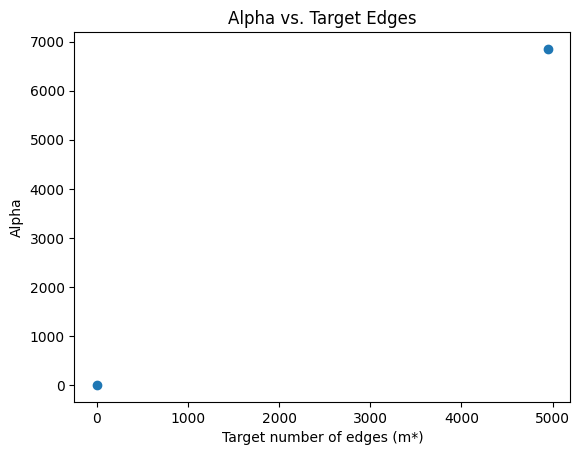

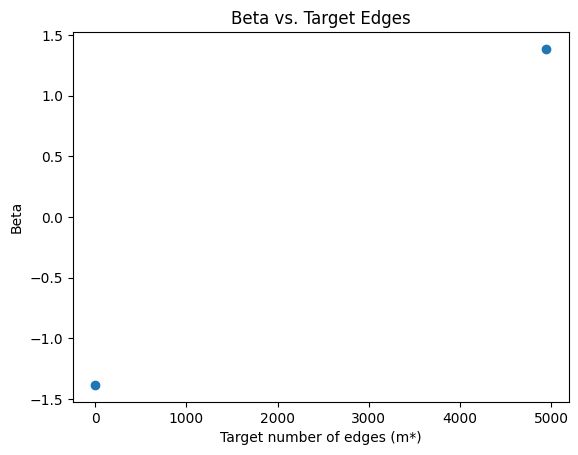

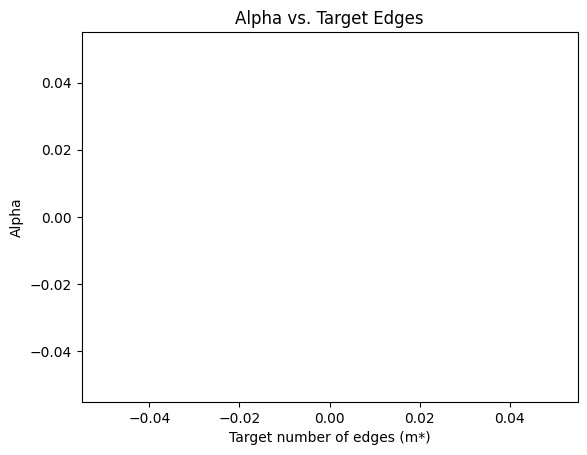

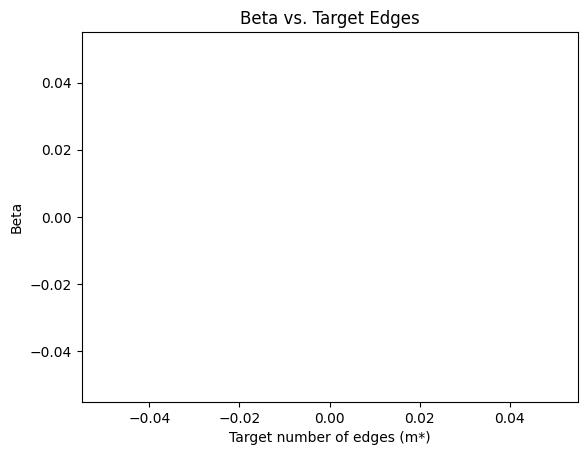

In [2]:
import mpmath
import numpy as np
import matplotlib.pyplot as plt

# Set precision (50 digits is sufficient for n=10, use 100+ for n>50)
mpmath.mp.dps = 50
mpmath.dps = 50

def solve_network_parameters(n, m_star):
    nc2 = int(mpmath.binomial(n, 2))
    
    # We derive the guess by matching the peak of the Gaussian to the Binomial.
    # 1. The Binomial coefficient at m_star is huge: B = binom(nc2, m_star)
    # 2. We need exp(-(alpha - beta*m)^2) * B approx 1 (Normalization)
    #    Therefore: (alpha - beta*m)^2 approx ln(B)
    # 3. We need the slopes to cancel at m_star (Derivative matching)
    
    # Log of the Binomial Coefficient (The "Height" we must suppress)
    ln_B = mpmath.log(mpmath.binomial(nc2, m_star))
    
    # The slope of the Log-Binomial distribution at m_star
    # S = ln((N - m)/m)
    binom_slope = mpmath.log((nc2 - m_star) / m_star)
    
    # Calculate parameters
    # delta represents (alpha - beta*m_star)
    delta = mpmath.sqrt(ln_B)
    
    # Derived Beta and Alpha
    # beta = -Slope / (2 * delta)
    beta_guess = -binom_slope / (2 * delta)
    alpha_guess = beta_guess * m_star + delta

    def equations(alpha, beta):
        total_prob = 0
        expected_edges = 0
        prev_total_prob = -1
        prev_expected_edges = -1
        for m in range(nc2 + 1):
            term = alpha - beta * m
            prob = mpmath.binomial(nc2, m) * mpmath.exp(-term*term)
            total_prob += prob
            expected_edges += m * prob
            if m>m_star and total_prob == prev_total_prob and expected_edges == prev_expected_edges:
                break
            prev_total_prob = total_prob
            prev_expected_edges = expected_edges
            
        return [total_prob - 1, expected_edges - m_star]

    def jacobian(alpha, beta):
        J11 = 0; J12 = 0; J21 = 0; J22 = 0
        prev_J = [None, None, None, None]
        for m in range(nc2 + 1):
            term = alpha - beta * m
            base_prob = mpmath.binomial(nc2, m) * mpmath.exp(-term**2)
            deriv_factor = -2 * term
            
            d_alpha = base_prob * deriv_factor
            d_beta = base_prob * deriv_factor * (-m)
            
            J11 += d_alpha; J12 += d_beta
            J21 += m * d_alpha; J22 += m * d_beta
            current_J = [J11, J12, J21, J22]
            
            # Only stop if we passed the target peak AND values stopped changing
            if m > m_star and current_J == prev_J:
                break
                
            prev_J = current_J
        return [[J11, J12], [J21, J22]]

    # --- 4. Solver Execution with Fallback ---
    # Priority 1: MDNewton (Fastest, Exact)
    # Priority 2: Anderson (Gradient-free, Robust against 0-derivatives)
    # Priority 3: Secant (Simple fallback)
    solvers = ['mdnewton', 'anderson', 'secant']
    
    for solver in solvers:
        try:
            kwargs = {'tol': 1e-10}
            if solver == 'mdnewton':
                kwargs['J'] = jacobian # Only pass Jacobian to Newton
            
            root = mpmath.findroot(equations, [alpha_guess, beta_guess], solver=solver, **kwargs)
            return float(root[0]), float(root[1])
            
        except Exception:
            continue
            
    print(f"  [Error] All solvers failed for m={m_star}")
    return None, None

# --- Verification Run ---
n = 100
nc2 = mpmath.binomial(n, 2)
# Testing the tricky range where previous codes failed
test_points = np.linspace(1, nc2-1, 2)

print(f"{'Target':<8} | {'Alpha':<10} | {'Beta':<10}")
print("-" * 35)

m_star_list = []
alpha_list = []
beta_list =[]
for m_star in test_points:
    alpha, beta = solve_network_parameters(n, m_star)
    if alpha is not None:
        print(f"{m_star} | {alpha} | {beta}")
        m_star_list.append(m_star)
        alpha_list.append(alpha)
        beta_list.append(beta)

plt.figure()
plt.scatter(m_star_list, alpha_list)
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Alpha')
plt.title('Alpha vs. Target Edges')
plt.figure()
plt.scatter(m_star_list, beta_list)
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Beta')
plt.title('Beta vs. Target Edges')

plt.figure()

plt.scatter(m_star_list[1:-1], alpha_list[1:-1])
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Alpha')
plt.title('Alpha vs. Target Edges')

plt.figure()
plt.scatter(m_star_list[1:-1], beta_list[1:-1])
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Beta')
plt.title('Beta vs. Target Edges')

plt.show()


n=10, m*=20, alpha=5.158281270203757, beta=-0.020064430594303476, Entropy=5.6481272947560344990102848904868159056935255572137, total_prob=0.99999999999999834183853299985788894180802151513773, expected_edges=19.999999999999968483033775862995739796633345359119
n=50, m*=100, alpha=12.102898328725798, beta=-0.06500000596819105, Entropy=18.629754639947621708069345474595633015558546454645, total_prob=1.0000000000102976826225894885690671019562882457699, expected_edges=100.00000000101097846221244416888562325576944837388
n=100, m*=200, alpha=17.993436980490134, beta=-0.05471233849669276, Entropy=28.953179452297135050041045528942665832337707917963, total_prob=0.99999999999995201112415531950714816717390354655543, expected_edges=199.99999999999034816835246075785977703409232456189
n=500, m*=1000, alpha=44.72822488472924, beta=-0.031572151123616235, Entropy=76.306928867303288148055364889425975272125202201849, total_prob=1.0000000000037976769449731213587477153089820298509, expected_edges=1000.0000000

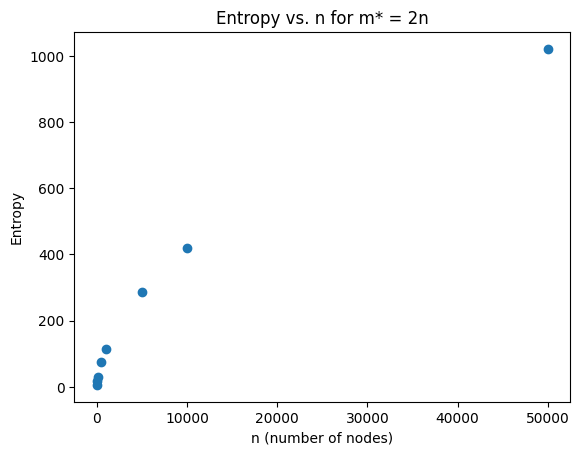

In [11]:
def solve_network_parameters(n, m_star):
    nc2 = int(mpmath.binomial(n, 2))
    
    # We derive the guess by matching the peak of the Gaussian to the Binomial.
    # 1. The Binomial coefficient at m_star is huge: B = binom(nc2, m_star)
    # 2. We need exp(-(alpha - beta*m)^2) * B approx 1 (Normalization)
    #    Therefore: (alpha - beta*m)^2 approx ln(B)
    # 3. We need the slopes to cancel at m_star (Derivative matching)
    
    # Log of the Binomial Coefficient (The "Height" we must suppress)
    ln_B = mpmath.log(mpmath.binomial(nc2, m_star))
    
    # The slope of the Log-Binomial distribution at m_star
    # S = ln((N - m)/m)
    binom_slope = mpmath.log((nc2 - m_star) / m_star)
    
    # Calculate parameters
    # delta represents (alpha - beta*m_star)
    delta = mpmath.sqrt(ln_B)
    
    # Derived Beta and Alpha
    # beta = -Slope / (2 * delta)
    beta_guess = -binom_slope / (2 * delta)
    alpha_guess = beta_guess * m_star + delta

    def equations(alpha, beta):
        total_prob = 0
        expected_edges = 0
        prev_total_prob = -1
        prev_expected_edges = -1
        for m in range(nc2 + 1):
            term = alpha - beta * m
            prob = mpmath.binomial(nc2, m) * mpmath.exp(-term*term)
            total_prob += prob
            expected_edges += m * prob
            if m>m_star and total_prob == prev_total_prob and expected_edges == prev_expected_edges:
                break
            prev_total_prob = total_prob
            prev_expected_edges = expected_edges
            
        return [total_prob - 1, expected_edges - m_star]

    def jacobian(alpha, beta):
        J11 = 0; J12 = 0; J21 = 0; J22 = 0
        prev_J = [None, None, None, None]
        for m in range(nc2 + 1):
            term = alpha - beta * m
            base_prob = mpmath.binomial(nc2, m) * mpmath.exp(-term**2)
            deriv_factor = -2 * term
            
            d_alpha = base_prob * deriv_factor
            d_beta = base_prob * deriv_factor * (-m)
            
            J11 += d_alpha; J12 += d_beta
            J21 += m * d_alpha; J22 += m * d_beta
            current_J = [J11, J12, J21, J22]
            
            # Only stop if we passed the target peak AND values stopped changing
            if m > m_star and current_J == prev_J:
                break
                
            prev_J = current_J
        return [[J11, J12], [J21, J22]]

    # --- 4. Solver Execution with Fallback ---
    # Priority 1: MDNewton (Fastest, Exact)
    # Priority 2: Anderson (Gradient-free, Robust against 0-derivatives)
    # Priority 3: Secant (Simple fallback)
    solvers = ['mdnewton', 'anderson', 'secant']
    
    for solver in solvers:
        try:
            kwargs = {'tol': 1e-10}
            if solver == 'mdnewton':
                kwargs['J'] = jacobian # Only pass Jacobian to Newton
            
            root = mpmath.findroot(equations, [alpha_guess, beta_guess], solver=solver, **kwargs)
            return float(root[0]), float(root[1])
            
        except Exception:
            continue
            
    print(f"  [Error] All solvers failed for m={m_star}")
    return None, None
def calculate_entropy(alpha, beta, nc2):
    nc2 = int(nc2)
    total_entropy = 0
    prev_total = -1
    for m in range(nc2 + 1):
        square_term = alpha - beta * m
        p = mpmath.exp(-square_term * square_term)
        entropy = p * mpmath.sqrt(-mpmath.log(p)) + (mpmath.sqrt(mpmath.pi) / 2) * mpmath.erfc(mpmath.sqrt(-mpmath.log(p)))
        total_entropy += mpmath.binomial(nc2, m) * entropy
        if total_entropy == prev_total:
            break
        prev_total = total_entropy
    return total_entropy

def check_equations(alpha, beta, nc2, m_star):
        total_prob = 0
        expected_edges = 0
        prev_total_prob = -1
        prev_expected_edges = -1
        for m in range(nc2 + 1):
            term = alpha - beta * m
            prob = mpmath.binomial(nc2, m) * mpmath.exp(-term*term)
            total_prob += prob
            expected_edges += m * prob
            if m>m_star and total_prob == prev_total_prob and expected_edges == prev_expected_edges:
                break
            prev_total_prob = total_prob
            prev_expected_edges = expected_edges
            
        return [total_prob, expected_edges]

entropy_list = []
n_list = []
for n in [10, 50, 100, 500, 1000, 5000, 10000, 50000]:
    nc2 = mpmath.binomial(n, 2)
    m_star = 2*n
    alpha, beta = solve_network_parameters(n, m_star)
    if alpha is not None:
        entropy = calculate_entropy(alpha, beta, nc2)
        entropy_list.append(float(entropy))
        n_list.append(n)
        total_prob, expected_edges = check_equations(alpha, beta, int(nc2), m_star)
        print(f"n={n}, m*={m_star}, alpha={alpha}, beta={beta}, Entropy={entropy}, total_prob={total_prob}, expected_edges={expected_edges}")

plt.figure()
plt.scatter(n_list, entropy_list)
plt.xlabel('n (number of nodes)')
plt.ylabel('Entropy')
plt.title('Entropy vs. n for m* = 2n')
plt.show() 

    


n=10, Entropy=30.9133
n=30, Entropy=174.5176
n=50, Entropy=346.3551
n=100, Entropy=837.6692
n=200, Entropy=1958.7569
n=300, Entropy=3184.4581
n=400, Entropy=4478.1102
n=500, Entropy=5822.2930
n=600, Entropy=7206.7451
n=700, Entropy=8624.6855
n=800, Entropy=10071.2948
n=900, Entropy=11542.9692
n=1000, Entropy=13036.9115


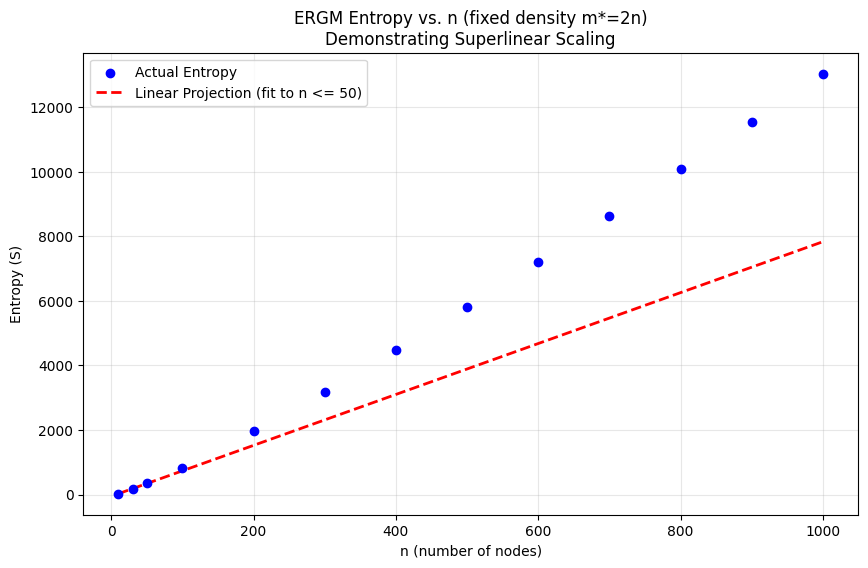

<Figure size 640x480 with 0 Axes>

In [ ]:
import mpmath
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Set precision for mpmath to handle large exponents/binomials
mpmath.mp.dps = 50

def solve_network_parameters(n, m_star):
    """
    Solves for the standard ERGM parameters (Bernoulli Graph / Erdős-Rényi).
    P(G) = exp(alpha + beta * m)
    """
    nc2 = mpmath.binomial(n, 2)
    
    # Probability of an edge existing
    p = m_star / nc2
    
    # In standard ERGM/Logistic regression: beta = logit(p)
    beta = mpmath.log(p / (1 - p))
    
    # Analytic simplification: alpha = nc2 * ln(1 - p)
    alpha = nc2 * mpmath.log(1 - p)
    
    return alpha, beta

def calculate_entropy(alpha, beta, nc2):
    nc2 = int(nc2)
    total_entropy = 0
    prev_total = -1
    
    # We iterate m starting from 0. 
    for m in range(nc2 + 1):
        log_p_g = alpha + beta * m
        p_g = mpmath.exp(log_p_g)
        
        num_graphs = mpmath.binomial(nc2, m)
        
        # S_shell = binom(nc2, m) * p_g * (-log_p_g)
        current_term = num_graphs * p_g * (-log_p_g)
        
        total_entropy += current_term
        
        # Convergence check
        if m > 10 and total_entropy == prev_total:
            break
            
        prev_total = total_entropy
        
    return total_entropy

ergm_entropy_list = []
# Sorted list for cleaner plotting
n_list = sorted([10, 30, 50, 100, 200, 300, 400, 600, 700, 800, 900, 500, 1000])

for n in n_list:
    nc2 = mpmath.binomial(n, 2)
    m_star = 2 * n
    
    # 1. Solve parameters analytically
    alpha, beta = solve_network_parameters(n, m_star)
    
    if alpha is not None:
        # 2. Calculate Entropy using loop summation
        entropy = calculate_entropy(alpha, beta, nc2)
        ergm_entropy_list.append(float(entropy))
        
        print(f"n={n}, Entropy={float(entropy):.4f}")

# Convert to numpy for regression
x = np.array(n_list)
y = np.array(ergm_entropy_list)

# --- Linear Fit ---
# Fit to the first 4 points (n=10 to n=100) to establish the initial "linear-looking" trend
limit_index = 3
slope, intercept, r_value, p_value, std_err = linregress(x[:limit_index], y[:limit_index])
y_pred = slope * x + intercept
import matplotlib
matplotlib.rcParams.update({'font.size': 18})
# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(x, y, c='blue', label='Actual Entropy', zorder=5)
plt.plot(x, y_pred, c='red', linestyle='--', linewidth=2, 
         label=f'Linear Projection (fit to n <= {n_list[limit_index-1]})')

plt.xlabel('n (number of nodes)')
plt.ylabel('Entropy (S)')
plt.title('ERGM Entropy vs. n (fixed density m*=2n)\nDemonstrating Superlinear Scaling')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.savefig('ergm_entropy_superlinear.png')

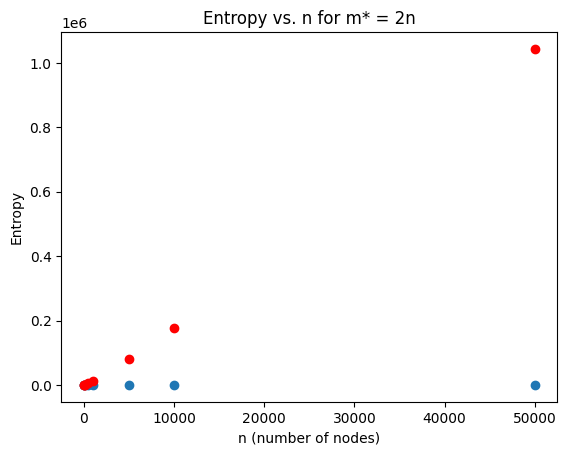

In [12]:
plt.figure()
plt.scatter(n_list, entropy_list)
plt.scatter(n_list, ergm_entropy_list, c='red', label='Standard ERGM')
plt.xlabel('n (number of nodes)')
plt.ylabel('Entropy')
plt.title('Entropy vs. n for m* = 2n')
plt.show() 

m*       | k* (2m/n)    | Alpha            | Beta            
--------------------------------------------------------------
1        | 0.020000     | 1.5651252545     | -69.1930313407  
101      | 2.020000     | 13.3924254460    | -4.3574852910   
202      | 4.040000     | 18.0706423299    | -2.7164274999   
303      | 6.060000     | 21.5085385967    | -2.0213707604   
404      | 8.080000     | 24.3345350303    | -1.6175300034   
505      | 10.100000    | 26.7855525369    | -1.3462598998   
606      | 12.120000    | 28.9811622257    | -1.1478596144   
707      | 14.140000    | 30.9917739823    | -0.9943121956   
808      | 16.160000    | 32.8631643137    | -0.8705447111   
909      | 18.180000    | 34.6272812386    | -0.7676489688   
1010     | 20.200000    | 36.3076786500    | -0.6799835164   
1111     | 22.220000    | 37.9225226052    | -0.6037801756   
1212     | 24.240000    | 39.4863804377    | -0.5364123709   
1313     | 26.260000    | 41.0113505339    | -0.4759836428   
1414   

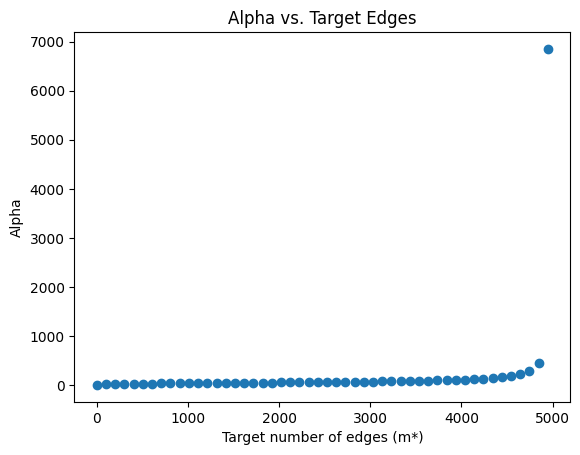

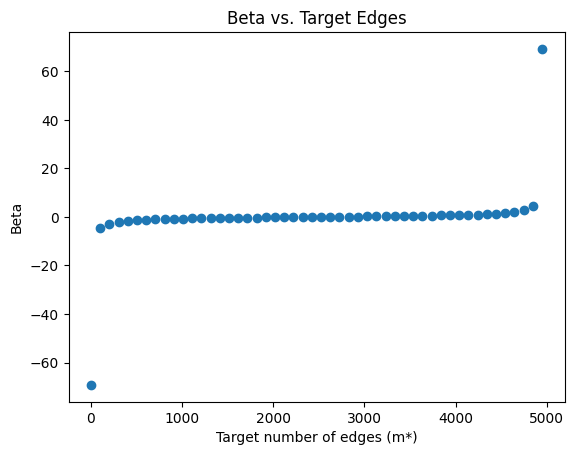

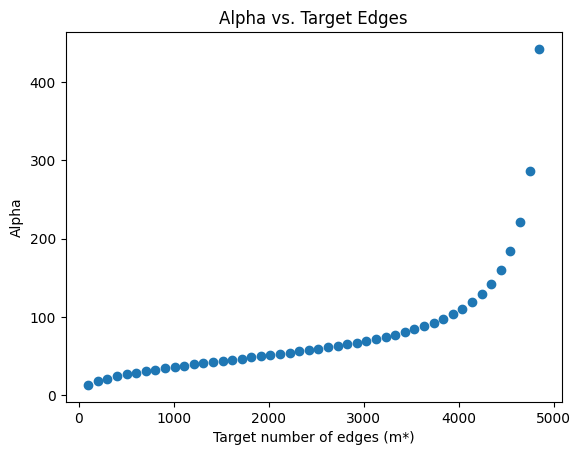

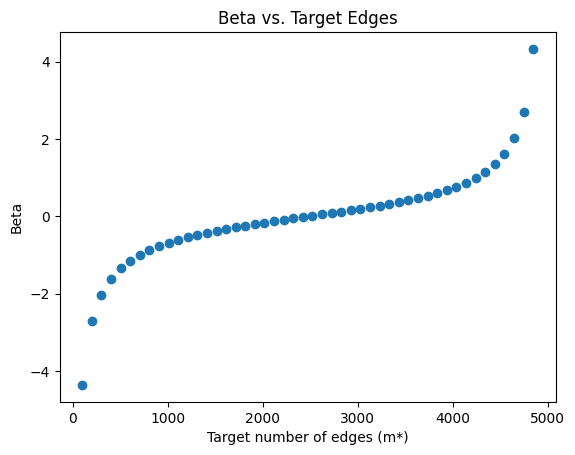

In [5]:
import mpmath
import numpy as np
import matplotlib.pyplot as plt

# Set precision
mpmath.mp.dps = 50
mpmath.dps = 50

def solve_network_parameters(n, m_star):
    """
    Solve for alpha, beta when the exponential term uses:
        exp(-(alpha - beta * (2*m)/n)^2)
    Input: n (nodes), m_star (target number of edges)
    Returns: (alpha, beta) such that total_prob ~1 and expected_edges ~ m_star
    """
    nc2 = int(mpmath.binomial(n, 2))

    # Log of the Binomial Coefficient (height to suppress)
    ln_B = mpmath.log(mpmath.binomial(nc2, m_star))

    # Slope of log-Binomial at m_star
    binom_slope = mpmath.log((nc2 - m_star) / m_star)

    # The coefficient multiplying m inside the Gaussian is beta_m = beta * (2/n).
    # Use the same logic as before to get initial guesses for beta_m and alpha, then convert.
    delta = mpmath.sqrt(ln_B)                    # delta ~= (alpha - beta_m * m_star)
    beta_m_guess = -binom_slope / (2 * delta)    # guess for beta_m (coefficient on m)
    beta_guess = beta_m_guess * (n / 2)          # convert back to beta
    alpha_guess = beta_m_guess * m_star + delta  # alpha is in the term alpha - beta_m * m

    def equations(alpha, beta):
        total_prob = mpmath.mpf('0')
        expected_edges = mpmath.mpf('0')
        prev_total_prob = None
        prev_expected_edges = None
        for m in range(nc2 + 1):
            term = alpha - beta * (2 * m) / n
            prob = mpmath.binomial(nc2, m) * mpmath.exp(-term * term)
            total_prob += prob
            expected_edges += m * prob

            # small optimization: if values stop changing after passing m_star, break
            if m > m_star and prev_total_prob is not None:
                if total_prob == prev_total_prob and expected_edges == prev_expected_edges:
                    break
            prev_total_prob = total_prob
            prev_expected_edges = expected_edges

        return [total_prob - 1, expected_edges - m_star]

    def jacobian(alpha, beta):
        J11 = mpmath.mpf('0'); J12 = mpmath.mpf('0')
        J21 = mpmath.mpf('0'); J22 = mpmath.mpf('0')
        prev_J = [None, None, None, None]
        for m in range(nc2 + 1):
            term = alpha - beta * (2 * m) / n
            base_prob = mpmath.binomial(nc2, m) * mpmath.exp(-term ** 2)

            # d/dalpha of exp(-term^2) = exp(-term^2) * (-2*term) * d(term)/dalpha
            deriv_factor = -2 * term
            d_alpha = base_prob * deriv_factor * (1)            # dterm/dalpha = 1
            # d/dbeta: dterm/dbeta = -(2*m)/n
            d_beta = base_prob * deriv_factor * (-(2 * m) / n)

            J11 += d_alpha; J12 += d_beta
            J21 += m * d_alpha; J22 += m * d_beta

            current_J = [J11, J12, J21, J22]
            if m > m_star and current_J == prev_J:
                break
            prev_J = current_J

        return [[J11, J12], [J21, J22]]

    # Solver loop with fallbacks
    solvers = ['mdnewton', 'anderson', 'secant']
    for solver in solvers:
        try:
            kwargs = {'tol': 1e-10}
            if solver == 'mdnewton':
                kwargs['J'] = jacobian
            root = mpmath.findroot(equations, [alpha_guess, beta_guess], solver=solver, **kwargs)
            return float(root[0]), float(root[1])
        except Exception:
            continue

    print(f"  [Error] All solvers failed for m={m_star}")
    return None, None

# --- Verification Run ---
n = 100
nc2 = int(mpmath.binomial(n, 2))

# Test points (avoid m=0 and m=nc2 to prevent log(0) inside guesses)
test_points = np.linspace(1, nc2 - 1, 50, dtype=int)

print(f"{'m*':<8} | {'k* (2m/n)':<12} | {'Alpha':<16} | {'Beta':<16}")
print("-" * 62)

m_star_list = []
k_star_list = []
alpha_list = []
beta_list = []
for m_star in test_points:
    alpha, beta = solve_network_parameters(n, int(m_star))
    if alpha is not None:
        k_star = 2 * m_star / n
        print(f"{m_star:<8} | {k_star:<12.6f} | {alpha:<16.10f} | {beta:<16.10f}")
        m_star_list.append(m_star)
        k_star_list.append(k_star)
        alpha_list.append(alpha)
        beta_list.append(beta)

# Quick scatter plots
plt.figure()
plt.scatter(m_star_list, alpha_list)
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Alpha')
plt.title('Alpha vs. Target Edges')

plt.figure()
plt.scatter(m_star_list, beta_list)
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Beta')
plt.title('Beta vs. Target Edges')

plt.figure()
plt.scatter(m_star_list[1:-1], alpha_list[1:-1])
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Alpha')
plt.title('Alpha vs. Target Edges')

plt.figure()
plt.scatter(m_star_list[1:-1], beta_list[1:-1])
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Beta')
plt.title('Beta vs. Target Edges')

plt.show()




In [ ]:
def calculate_entropy(alpha, beta, nc2):
    nc2 = int(nc2)
    total_entropy = 0
    prev_total = -1
    for m in range(nc2 + 1):
        square_term = alpha - beta * m
        p = mpmath.exp(-square_term * square_term)
        entropy = p * mpmath.sqrt(-mpmath.log(p)) + (mpmath.sqrt(mpmath.pi) / 2) * mpmath.erfc(mpmath.sqrt(-mpmath.log(p)))
        total_entropy += mpmath.binomial(nc2, m) * entropy
        if total_entropy == prev_total:
            break
        prev_total = total_entropy
    return total_entropy